# Similarity search with a frozen AstroPT backbone

Loads the same released [`Smith42/astroPT`](https://huggingface.co/Smith42/astroPT)
checkpoint as `astropt_finetuning.ipynb`, but uses it purely as a
frozen feature extractor (no finetuning) on
[`Smith42/galaxies`](https://huggingface.co/datasets/Smith42/galaxies) —
the reference authors' own probing dataset, streamed (first 2,000 examples
with a measured `mag_g`; see `utils/galaxies.py`), rather than reusing
GZ10 a fourth time. Computes one embedding per galaxy, then ranks the
dataset by cosine similarity to a query galaxy's embedding and inspects its
nearest neighbors, following the reference model's
`scripts/euclid/downstream_tasks/similarity_search.py`.

That reference script keys everything to a Euclid FITS/catalog pipeline
(datacubes, object-property tables); here the query/neighbor galaxies are
shown directly from their images and `mag_g` (g-band magnitude — Smith42/galaxies
has no discrete class label), and the 2D layout uses `sklearn.manifold.TSNE`
in place of UMAP, matching `gcnn_analysis.ipynb`'s reasoning for
reusing the already-installed `scikit-learn` dependency.

## Install example-only dependencies

Not part of AstroLens' core install (`requirements.txt`) — only needed for this example.

In [1]:
!pip install -q datasets torchvision scikit-learn huggingface_hub matplotlib

## Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from torch.utils.data import DataLoader
from torchvision import transforms

from utils import galaxies
from utils.astropt import compute_embeddings, load_pretrained_astropt

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load the dataset, backbone, and embeddings

Streams `N_EXAMPLES` from `Smith42/galaxies` (`utils/galaxies.py`) —
embedding-based analysis only needs inference, no training data. The model
has no task head and no LoRA adapters (`load_pretrained_astropt` defaults
to `num_classes=0`, `lora_r=0`): the whole backbone stays frozen and is
used only through `forward_features`, mean-pooled into one embedding per
galaxy by `compute_embeddings` (see `astropt_finetuning.ipynb` for
what `load_pretrained_astropt` transfers from the checkpoint and why).

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 64
N_EXAMPLES = 200
PROPERTY_KEY = "mag_g"

examples = galaxies.load_galaxies(N_EXAMPLES, columns=["image", PROPERTY_KEY], filter_key=PROPERTY_KEY)
properties = np.array([example[PROPERTY_KEY] for example in examples])

# no pixel Normalize here: AstroPT.patchify normalizes each patch to zero
# mean/unit variance itself, matching the reference model's pretraining input
eval_transform = transforms.Compose(
    [
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
    ]
)

dataset = galaxies.GalaxiesDataset(examples, eval_transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, num_workers=4)

model = load_pretrained_astropt(IMG_SIZE, device)
embeddings = compute_embeddings(model, loader, device)

embeddings.shape

Resolving data files:   0%|          | 0/1533 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1533 [00:00<?, ?it/s]

streaming galaxies:   0%|          | 0/200 [00:00<?, ?ex/s]

embedding:   0%|          | 0/4 [00:00<?, ?batch/s]

(200, 768)

## Similarity search

Ranks every galaxy by cosine similarity to a query galaxy's embedding and
shows its nearest neighbors, following `similarity_search.py`'s core step
(`cosine_similarity(query_embedding, embeddings)` + `argsort`), against a
`sklearn.manifold.TSNE` projection of the embeddings for context.

Text(0.5, 0.98, 'Nearest neighbors of query 0')

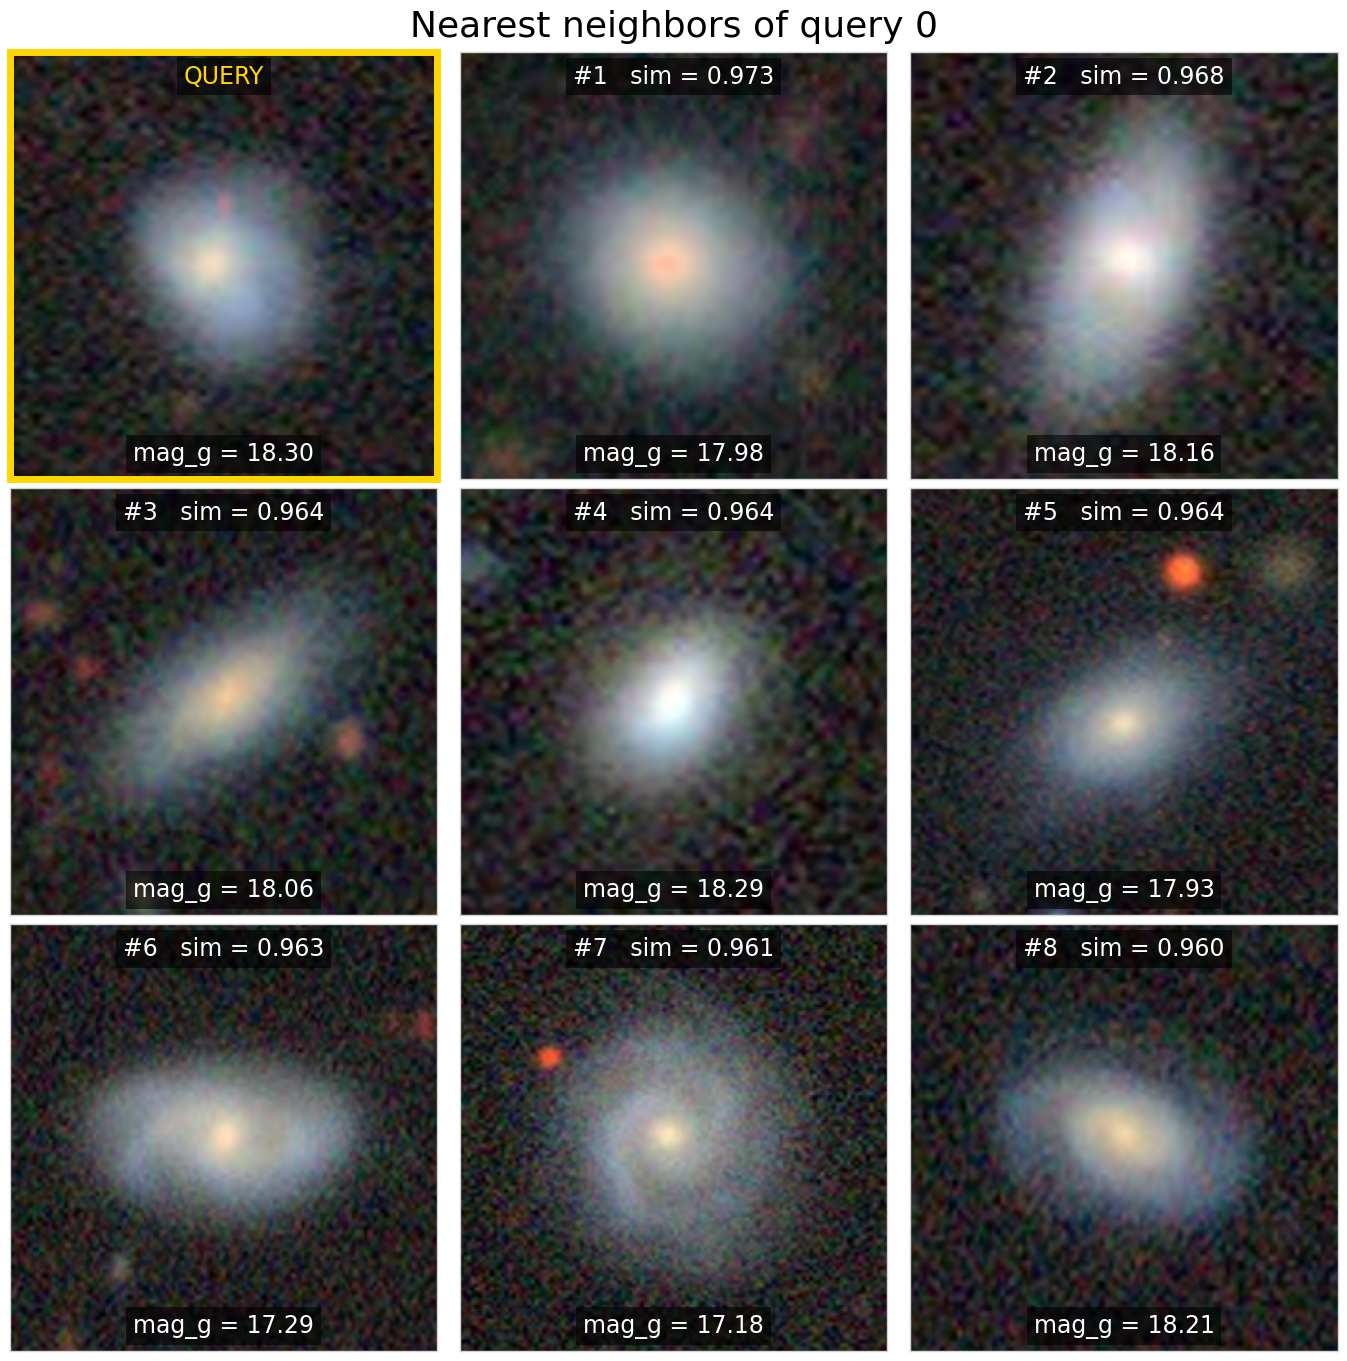

In [4]:
TOP_N = 8
N_COLS = 3
QUERY_IDX = 0  # pick any position

sims = cosine_similarity(embeddings[QUERY_IDX : QUERY_IDX + 1], embeddings)[0]
nearest = np.argsort(sims)[::-1][: TOP_N + 1]  # includes the query itself

n_rows = int(np.ceil(len(nearest) / N_COLS))
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(4.5 * N_COLS, 4.5 * n_rows), layout="constrained")
for rank, (ax, idx) in enumerate(zip(axes.flat, nearest)):
    image = dataset[idx]
    is_query = idx == QUERY_IDX
    ax.imshow(image.permute(1, 2, 0).numpy())
    ax.text(
        0.5,
        0.97,
        "QUERY" if is_query else f"#{rank}   sim = {sims[idx]:.3f}",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=17,
        color="gold" if is_query else "white",
        bbox=dict(facecolor="black", alpha=0.6, edgecolor="none", pad=5),
    )
    ax.text(
        0.5,
        0.03,
        f"{PROPERTY_KEY} = {properties[idx]:.2f}",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=17,
        color="white",
        bbox=dict(facecolor="black", alpha=0.6, edgecolor="none", pad=5),
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set(color="gold" if is_query else "lightgray", linewidth=5 if is_query else 1)
for ax in axes.flat[len(nearest) :]:
    ax.axis("off")
fig.suptitle(f"Nearest neighbors of query {QUERY_IDX}", fontsize=26)


[]

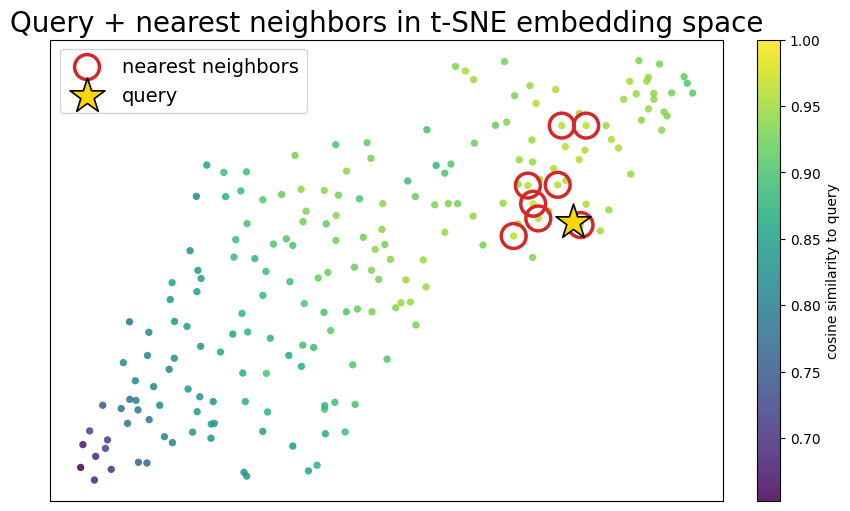

In [5]:
projection = TSNE(n_components=2, random_state=0, init="pca").fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
points = ax.scatter(*projection.T, c=sims, cmap="viridis", s=28, alpha=0.85, linewidths=0)
ax.scatter(
    *projection[nearest[1:]].T,
    s=320,
    facecolors="none",
    edgecolors="tab:red",
    linewidths=2.5,
    label="nearest neighbors",
)
ax.scatter(
    *projection[QUERY_IDX], marker="*", s=700, c="gold", edgecolors="black", linewidths=1.2, label="query"
)
fig.colorbar(points, ax=ax, label="cosine similarity to query")
ax.legend(fontsize=14, loc="best")
ax.set_title("Query + nearest neighbors in t-SNE embedding space", fontsize=20)
ax.set_xticks([])
ax.set_yticks([])
